In [ ]:
# ============================================================
# 1. DATA PREPROCESSING
# ============================================================

import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
import joblib
import warnings
warnings.filterwarnings("ignore")

from pandas.api import types as ptypes
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve,
    confusion_matrix, classification_report, accuracy_score
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import shap
import scipy.sparse as sp

RND = 42
np.random.seed(RND)

# ---------------------------
# Path konfigurasi
# ---------------------------
DATA_PATH = "cardio.csv"   # ganti dengan path dataset kamu
SAVE_DIR = "models_cardio"
os.makedirs(SAVE_DIR, exist_ok=True)

# ---------------------------
# Load data
# ---------------------------
df = pd.read_csv(DATA_PATH)
print("Raw dataframe shape:", df.shape)
display(df.head(5))

# ---------------------------
# Basic cleaning
# ---------------------------
df.columns = [c.strip() for c in df.columns]  # hapus spasi di nama kolom
df = df.dropna(how="all").reset_index(drop=True)  # hapus baris kosong total

# jika ada kolom id, hapus dari fitur
id_col = None
for cand in ["id", "ID", "patient_id", "PatientID"]:
    if cand in df.columns:
        id_col = cand
        break
if id_col:
    df = df.drop(columns=[id_col])

# jika kolom age masih dalam hari, ubah ke tahun
if "age" in df.columns and ("age_years" not in df.columns):
    if df["age"].median() > 100:  # deteksi kalau dalam hari
        df["age_years"] = (df["age"] / 365).round().astype(int)
    else:
        df["age_years"] = df["age"].astype(int)

# hitung BMI jika belum ada
if "bmi" not in df.columns and {"height", "weight"}.issubset(df.columns):
    df["bmi"] = df["weight"] / ((df["height"]/100)**2)
    df["bmi"] = df["bmi"].replace([np.inf, -np.inf], np.nan)

# hilangkan spasi di nilai string
for c in df.select_dtypes(include="object").columns:
    df[c] = df[c].str.strip()

# ---------------------------
# Target processing
# ---------------------------
target_col = None
for cand in ["cardio","Cardio","cardiovascular","Heart_Disease","Heart Disease","cardio_target"]:
    if cand in df.columns:
        target_col = cand
        break
if not target_col:
    target_col = df.columns[-1]
    print("Target not found by standard names, using last column:", target_col)

# ubah target menjadi biner 0/1
def to_binary_series(s):
    if ptypes.is_numeric_dtype(s):
        return s.fillna(0).astype(int)
    s2 = s.astype(str).str.strip().str.lower()
    m = s2.map({"yes":1,"y":1,"true":1,"1":1,"positive":1,
                "no":0,"n":0,"false":0,"0":0,"negative":0})
    if m.isna().sum() > 0:
        fac, uniq = pd.factorize(s2)
        if len(uniq) == 2:
            return pd.Series(fac, index=s.index)
        else:
            m = m.fillna(0)
    return m.astype(int)

df[target_col] = to_binary_series(df[target_col])
print("Target distribution:\n", df[target_col].value_counts(normalize=True))

# ---------------------------
# Feature selection / deteksi tipe kolom
# ---------------------------
features = [c for c in df.columns if c != target_col]
num_cols = [c for c in features if ptypes.is_numeric_dtype(df[c])]
cat_cols = []

# deteksi categorical secara otomatis (low-cardinality)
for c in features:
    if c not in num_cols:
        cat_cols.append(c)
    elif df[c].nunique() <= 20:
        cat_cols.append(c)
num_cols = [c for c in features if c not in cat_cols]

print("Numeric cols:", num_cols)
print("Categorical cols:", cat_cols)

# imputasi nilai hilang
num_imputer = SimpleImputer(strategy="median")
df[num_cols] = pd.DataFrame(num_imputer.fit_transform(df[num_cols]), columns=num_cols)

for c in cat_cols:
    df[c] = df[c].fillna("Missing").astype(str)

# pisahkan X dan y
X = df[[c for c in df.columns if c != target_col]].copy()
y = df[target_col].copy()

Raw dataframe shape: (68205, 17)


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years,bmi,bp_category,bp_category_encoded
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0,50,21.967120,Hypertension Stage 1,Hypertension Stage 1
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1,55,34.927679,Hypertension Stage 2,Hypertension Stage 2
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1,51,23.507805,Hypertension Stage 1,Hypertension Stage 1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1,48,28.710479,Hypertension Stage 2,Hypertension Stage 2
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0,47,23.011177,Normal,Normal


Target distribution:
 cardio
0    0.506312
1    0.493688
Name: proportion, dtype: float64
Numeric cols: ['age', 'height', 'weight', 'ap_hi', 'ap_lo', 'age_years', 'bmi']
Categorical cols: ['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'bp_category', 'bp_category_encoded']


In [2]:
# ============================================================
# 2. FEATURE ENGINEERING
# ============================================================

# contoh feature turunan: tekanan darah rata-rata & pulse pressure
if {"ap_hi", "ap_lo"}.issubset(df.columns):
    X["bp_mean"] = (df["ap_hi"] + df["ap_lo"]) / 2
    X["pulse_pressure"] = df["ap_hi"] - df["ap_lo"]
    num_cols += ["bp_mean", "pulse_pressure"]

# interaksi umur dan BMI
if "age_years" in X.columns and "bmi" in X.columns:
    X["age_x_bmi"] = X["age_years"] * X["bmi"]
    num_cols.append("age_x_bmi")

# smoke dikonversi ke bentuk numerik biner jika ada
if "smoke" in X.columns and "age_years" in X.columns:
    try:
        X["smoke_bin"] = pd.to_numeric(X["smoke"], errors="coerce").fillna(0).astype(int)
    except Exception:
        X["smoke_bin"] = X["smoke"].apply(lambda v: 1 if str(v).strip().lower() in ["1","yes","y","true"] else 0)
    num_cols.append("smoke_bin")

# deduplikasi
num_cols = list(dict.fromkeys([c for c in num_cols if c in X.columns]))
cat_cols = list(dict.fromkeys([c for c in cat_cols if c in X.columns and c not in num_cols]))

print("Final numeric cols:", len(num_cols))
print("Final categorical cols:", len(cat_cols))

# split data untuk train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RND
)
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

Final numeric cols: 11
Final categorical cols: 8
Train shape: (54564, 19) Test shape: (13641, 19)


In [3]:
# ============================================================
# 3. MODEL DEVELOPMENT (TRAINING & TUNING)
# ============================================================

# preprocessing pipeline: scale numerik, OHE kategorikal
try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

numeric_transformer = Pipeline([("scaler", StandardScaler())])
categorical_transformer = Pipeline([("ohe", ohe)])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols)
])

# baseline model pipeline
xgb_pipe = Pipeline([
    ("preproc", preprocessor),
    ("model", XGBClassifier(use_label_encoder=False, eval_metric="auc", random_state=RND, n_jobs=-1))
])
lgb_pipe = Pipeline([
    ("preproc", preprocessor),
    ("model", LGBMClassifier(random_state=RND, n_jobs=-1))
])

# fit baseline models
print("\nTraining baseline XGB/LGB ...")
t0 = time.time()
xgb_pipe.fit(X_train, y_train)
lgb_pipe.fit(X_train, y_train)
print("Training done in %.1f s" % (time.time() - t0))

# RandomizedSearchCV untuk tuning
cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=RND)

xgb_param_dist = {
    "model__n_estimators": [200,400,800],
    "model__max_depth": [3,5,7],
    "model__learning_rate": [0.01,0.03,0.05],
    "model__subsample": [0.6,0.8,1.0],
    "model__colsample_bytree": [0.6,0.8,1.0],
    "model__reg_alpha": [0,0.1,0.5],
    "model__reg_lambda": [1,2,5]
}

lgb_param_dist = {
    "model__n_estimators": [200,400,800],
    "model__num_leaves": [31,63,127],
    "model__learning_rate": [0.01,0.03,0.05],
    "model__subsample": [0.6,0.8,1.0],
    "model__colsample_bytree": [0.6,0.8,1.0],
    "model__reg_alpha": [0,0.1,0.5],
    "model__reg_lambda": [0,0.1,1.0]
}

N_ITER = 24  # jumlah iterasi tuning

# tuning XGB
xgb_rs = RandomizedSearchCV(xgb_pipe, xgb_param_dist, n_iter=N_ITER, scoring="roc_auc",
                            cv=cv, random_state=RND, n_jobs=-1, verbose=1)
xgb_rs.fit(X_train, y_train)
best_xgb = xgb_rs.best_estimator_
print("Best XGB params:", xgb_rs.best_params_)

# tuning LGB
lgb_rs = RandomizedSearchCV(lgb_pipe, lgb_param_dist, n_iter=N_ITER, scoring="roc_auc",
                            cv=cv, random_state=RND, n_jobs=-1, verbose=1)
lgb_rs.fit(X_train, y_train)
best_lgb = lgb_rs.best_estimator_
print("Best LGB params:", lgb_rs.best_params_)


Training baseline XGB/LGB ...
[LightGBM] [Info] Number of positive: 26938, number of negative: 27626
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003500 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1404
[LightGBM] [Info] Number of data points in the train set: 54564, number of used features: 33
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.493695 -> initscore=-0.025219
[LightGBM] [Info] Start training from score -0.025219
Training done in 1.1 s
Fitting 4 folds for each of 24 candidates, totalling 96 fits
Best XGB params: {'model__subsample': 0.8, 'model__reg_lambda': 1, 'model__reg_alpha': 0, 'model__n_estimators': 400, 'model__max_depth': 5, 'model__learning_rate': 0.01, 'model__colsample_bytree': 0.6}
Fitting 4 folds for each of 24 candidates, totalling 96 fits
[LightGBM] [Info] Number of positive: 26938, number of negative


--- XGBoost (tuned) ---
ROC AUC: 0.8034 | PR AUC: 0.7867
              precision    recall  f1-score   support

           0     0.7167    0.7912    0.7521      6907
           1     0.7603    0.6792    0.7175      6734

    accuracy                         0.7359     13641
   macro avg     0.7385    0.7352    0.7348     13641
weighted avg     0.7382    0.7359    0.7350     13641



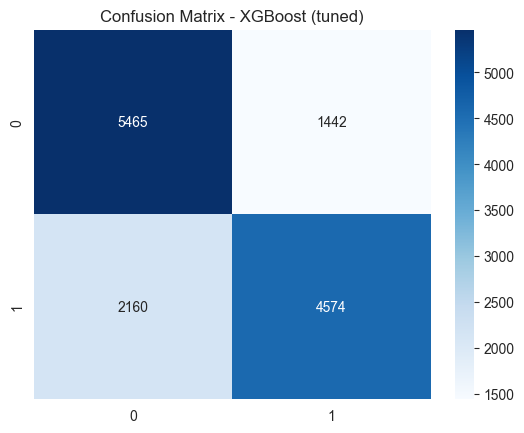


--- LightGBM (tuned) ---
ROC AUC: 0.8032 | PR AUC: 0.7877
              precision    recall  f1-score   support

           0     0.7210    0.7838    0.7511      6907
           1     0.7565    0.6889    0.7211      6734

    accuracy                         0.7370     13641
   macro avg     0.7388    0.7364    0.7361     13641
weighted avg     0.7385    0.7370    0.7363     13641



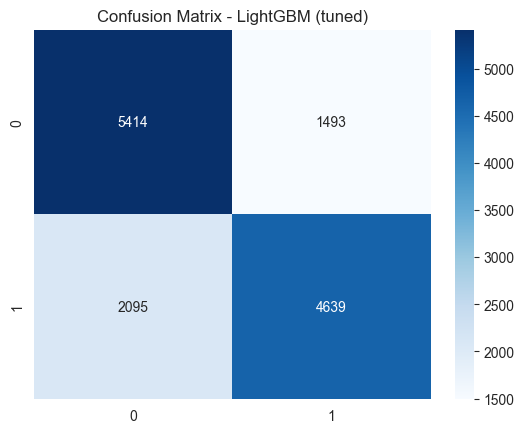

XGB CV mean/std: 0.8009537226190568 0.003407541770255252
LGB CV mean/std: 0.8012168364659071 0.003268088933001199


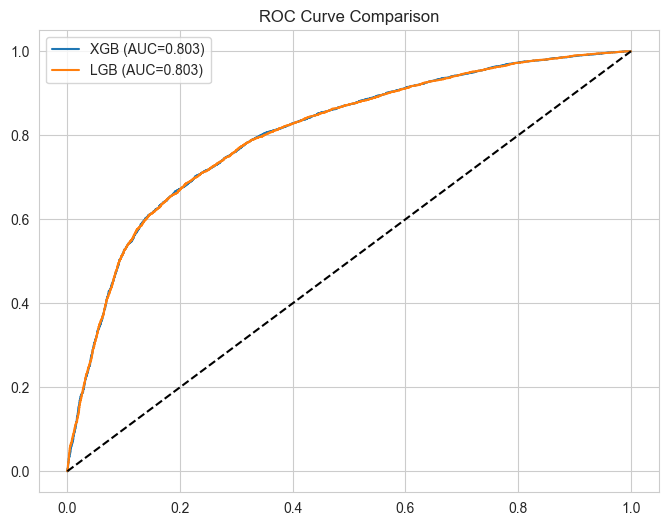

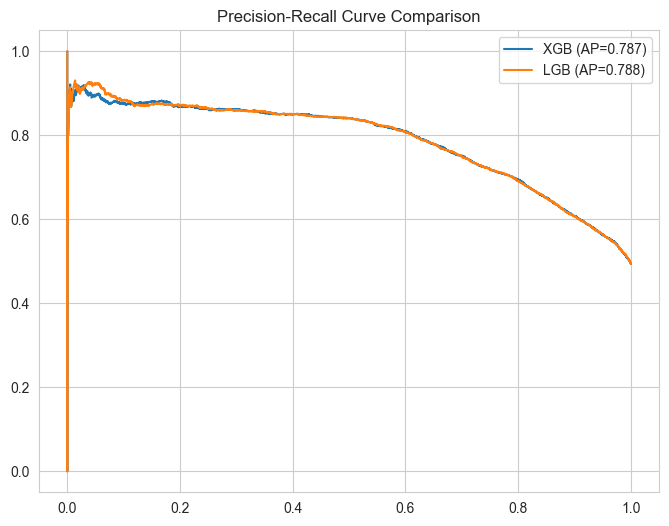

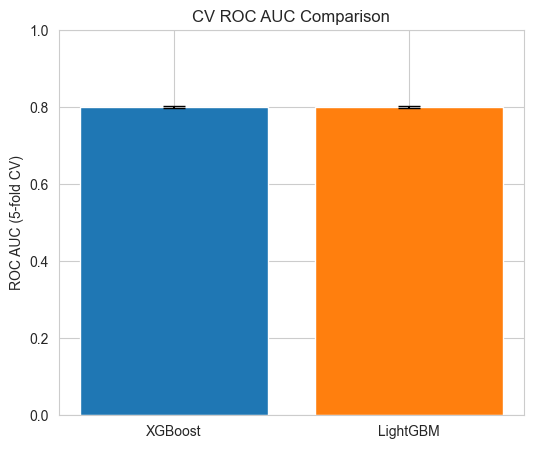

In [4]:
# ============================================================
# 4. MODEL EVALUATION
# ============================================================

def evaluate_pipe(pipe, Xv, yv, name="Model"):
    """Evaluasi model: menghitung ROC AUC, PR AUC, dan menampilkan confusion matrix."""
    prob = pipe.predict_proba(Xv)[:,1]
    pred = (prob >= 0.5).astype(int)
    roc = roc_auc_score(yv, prob)
    pr = average_precision_score(yv, prob)
    print(f"\n--- {name} ---")
    print(f"ROC AUC: {roc:.4f} | PR AUC: {pr:.4f}")
    print(classification_report(yv, pred, digits=4))
    cm = confusion_matrix(yv, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {name}")
    plt.show()
    return prob, roc, pr

# evaluasi model tuned
prob_xgb, roc_xgb, pr_xgb = evaluate_pipe(best_xgb, X_test, y_test, "XGBoost (tuned)")
prob_lgb, roc_lgb, pr_lgb = evaluate_pipe(best_lgb, X_test, y_test, "LightGBM (tuned)")

# cross-validation
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RND)
cv_xgb = cross_val_score(best_xgb, X, y, cv=cv5, scoring="roc_auc", n_jobs=-1)
cv_lgb = cross_val_score(best_lgb, X, y, cv=cv5, scoring="roc_auc", n_jobs=-1)
print("XGB CV mean/std:", cv_xgb.mean(), cv_xgb.std())
print("LGB CV mean/std:", cv_lgb.mean(), cv_lgb.std())

# visualisasi ROC & PR
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, prob_xgb)
fpr_lgb, tpr_lgb, _ = roc_curve(y_test, prob_lgb)
plt.figure(figsize=(8,6))
plt.plot(fpr_xgb, tpr_xgb, label=f"XGB (AUC={roc_xgb:.3f})")
plt.plot(fpr_lgb, tpr_lgb, label=f"LGB (AUC={roc_lgb:.3f})")
plt.plot([0,1],[0,1],'k--')
plt.title("ROC Curve Comparison")
plt.legend(); plt.show()

prec_xgb, rec_xgb, _ = precision_recall_curve(y_test, prob_xgb)
prec_lgb, rec_lgb, _ = precision_recall_curve(y_test, prob_lgb)
plt.figure(figsize=(8,6))
plt.plot(rec_xgb, prec_xgb, label=f"XGB (AP={pr_xgb:.3f})")
plt.plot(rec_lgb, prec_lgb, label=f"LGB (AP={pr_lgb:.3f})")
plt.title("Precision-Recall Curve Comparison")
plt.legend(); plt.show()

# CV AUC bar chart
labels = ["XGBoost", "LightGBM"]
means = [cv_xgb.mean(), cv_lgb.mean()]
stds = [cv_xgb.std(), cv_lgb.std()]
plt.figure(figsize=(6,5))
plt.bar(labels, means, yerr=stds, capsize=8, color=["#1f77b4","#ff7f0e"])
plt.ylim(0,1)
plt.ylabel("ROC AUC (5-fold CV)")
plt.title("CV ROC AUC Comparison")
plt.show()

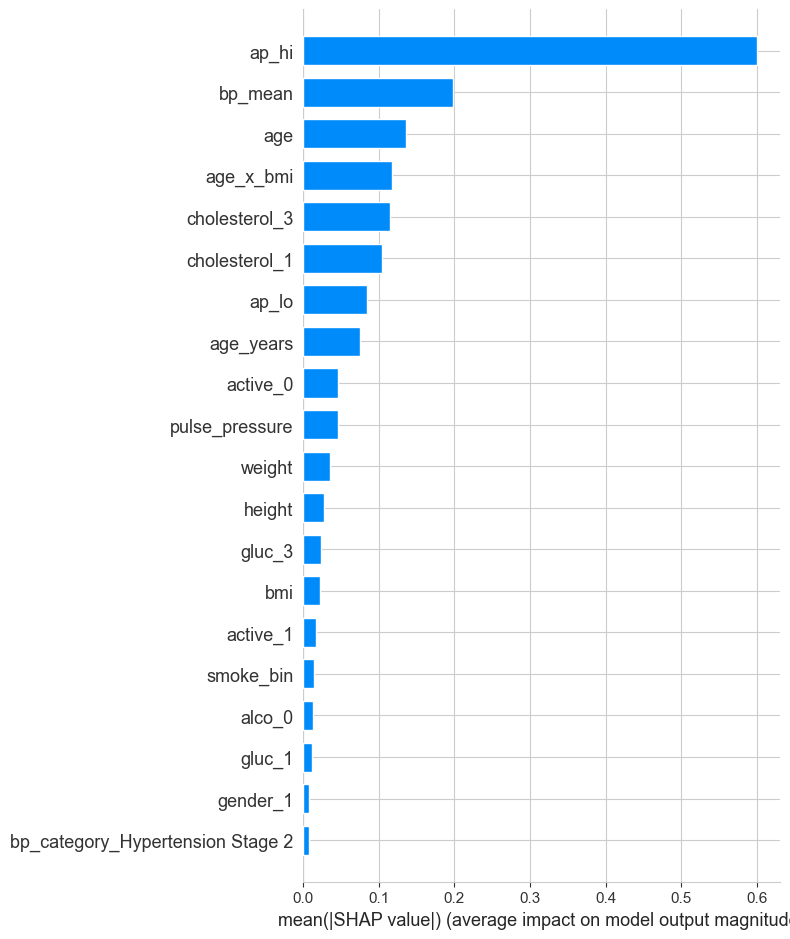

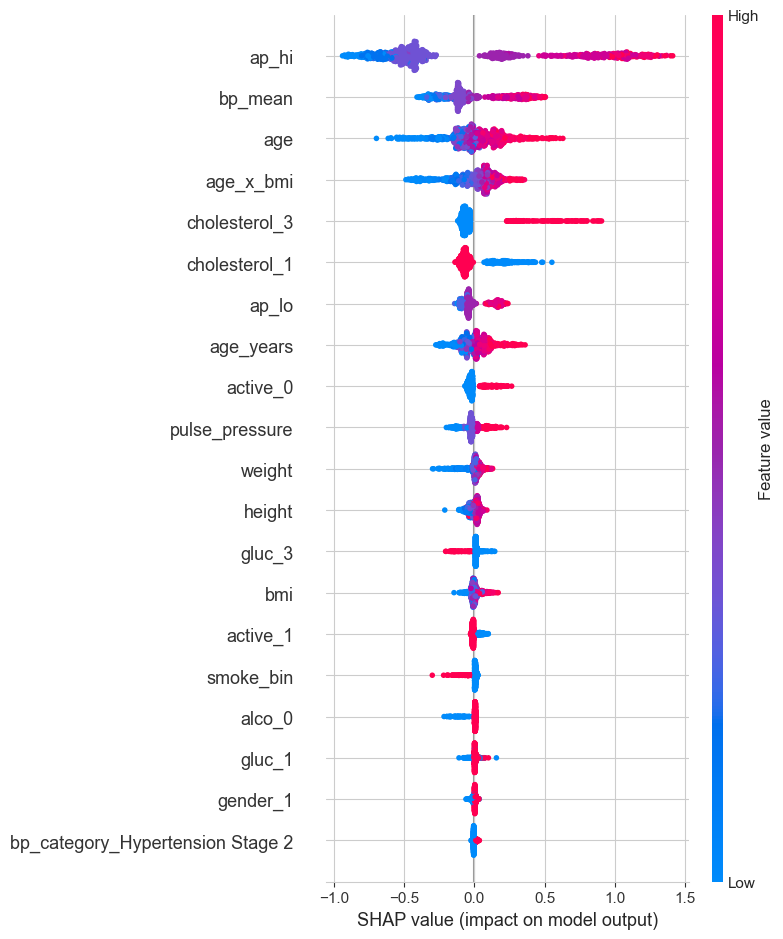

Top feature by importance: age


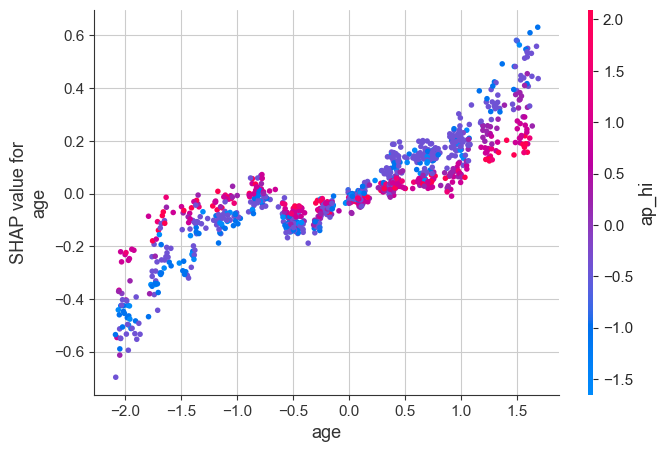

Model disimpan di: models_cardio


In [5]:
# ============================================================
# 5. MODEL VALIDATION USING EXPLAINABLE AI (SHAP)
# ============================================================

# ambil feature names setelah preprocessing
def get_feature_names_after_preprocessing(column_transformer, numeric_features, categorical_features):
    """Ambil nama kolom setelah transformasi (numerik + OHE kategorikal)."""
    feature_names = []
    feature_names.extend(numeric_features)
    if "cat" in dict(column_transformer.named_transformers_).keys():
        ohe_step = column_transformer.named_transformers_["cat"].named_steps["ohe"]
        cat_names = list(ohe_step.get_feature_names_out(categorical_features))
        feature_names.extend(cat_names)
    return feature_names

preproc = best_lgb.named_steps["preproc"]
feature_names = get_feature_names_after_preprocessing(preproc, num_cols, cat_cols)

# transform X_test ke format numerik penuh
X_test_trans = preproc.transform(X_test)
if sp.issparse(X_test_trans):
    X_test_trans = X_test_trans.toarray()
X_test_trans_df = pd.DataFrame(X_test_trans, columns=feature_names, index=X_test.index)

# sample 1000 data untuk SHAP
X_shap = X_test_trans_df.sample(n=min(1000, X_test_trans_df.shape[0]), random_state=RND)
lgb_model = best_lgb.named_steps["model"]

# SHAP Explainer
explainer = shap.TreeExplainer(lgb_model)
shap_values = explainer.shap_values(X_shap)

# Plot summary importance
shap.summary_plot(shap_values, X_shap, plot_type="bar", max_display=20)
shap.summary_plot(shap_values, X_shap, max_display=20)

# Dependence plot fitur teratas
fi = pd.Series(lgb_model.feature_importances_, index=feature_names).sort_values(ascending=False)
top_feat = fi.index[0]
print("Top feature by importance:", top_feat)
shap.dependence_plot(top_feat, shap_values, X_shap)

# Simpan model tuned
joblib.dump(best_xgb, os.path.join(SAVE_DIR, "best_xgb_pipeline.joblib"))
joblib.dump(best_lgb, os.path.join(SAVE_DIR, "best_lgb_pipeline.joblib"))
print("Model disimpan di:", SAVE_DIR)